In [2]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn 
!pip install sklearn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement sklearn (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for sklearn


In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
df = pd.read_csv('C:/Users/SRIVIDYA GAJJALA/Datasets/preprocessed_earthquake_data_v3.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109848 entries, 0 to 109847
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   latitude          109848 non-null  float64
 1   longitude         109848 non-null  float64
 2   depth             109848 non-null  float64
 3   mag               109848 non-null  float64
 4   magType           109848 non-null  object 
 5   rms               109848 non-null  float64
 6   type              109848 non-null  object 
 7   status            109848 non-null  object 
 8   Year              109848 non-null  int64  
 9   Month             109848 non-null  int64  
 10  Day               109848 non-null  int64  
 11  Hour              109848 non-null  int64  
 12  Minute            109848 non-null  int64  
 13  Second            109848 non-null  int64  
 14  DayOfWeek         109848 non-null  int64  
 15  Mw                109715 non-null  float64
 16  damage_potential  10

EDA Task1:analyze earthquake frequency and magnitude trends over time.

To analyze how earthquake frequency and magnitude trends change over time — across years, months, and days of the week.

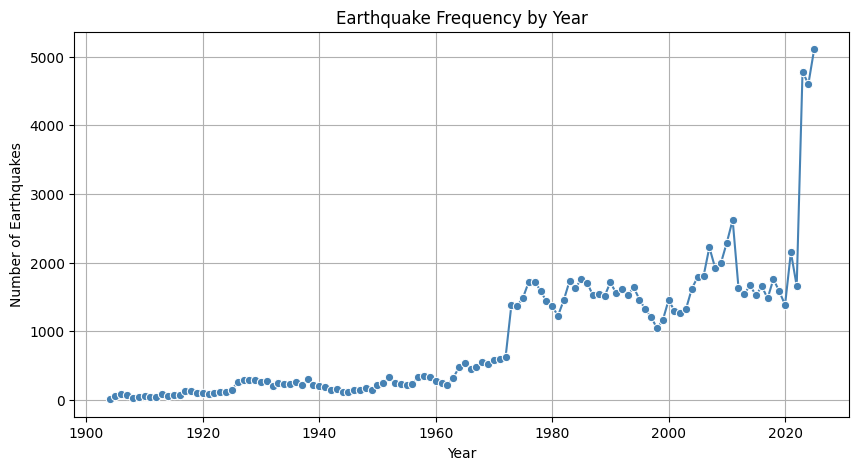

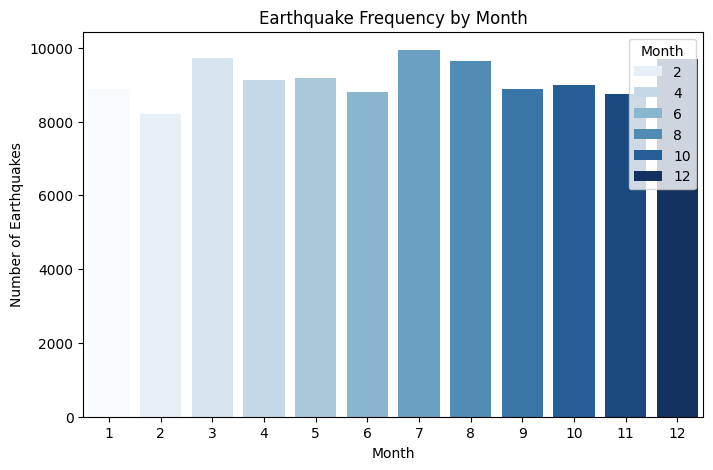

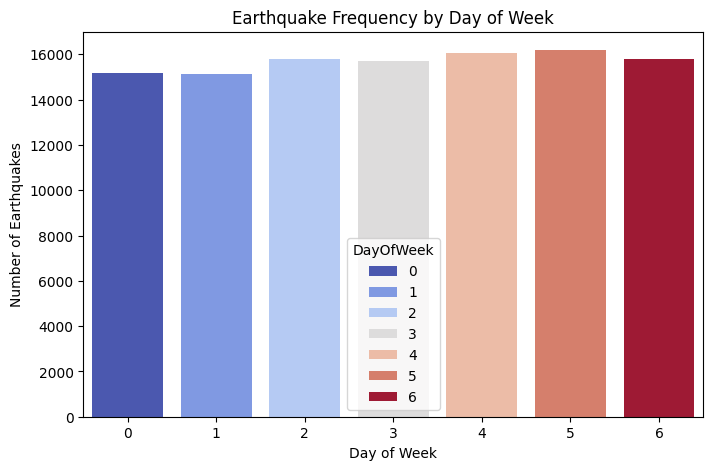

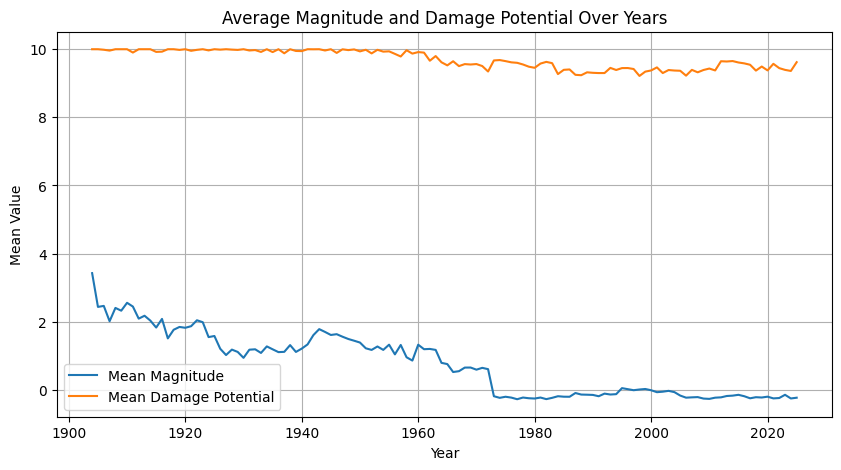

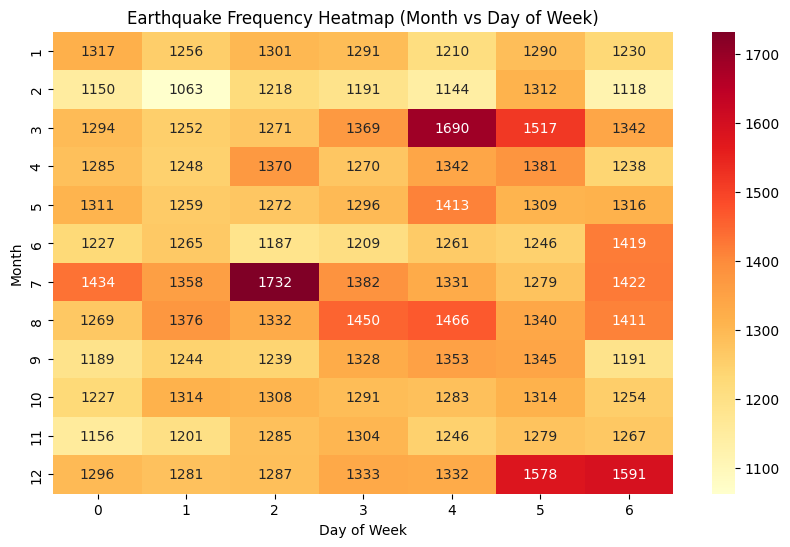

In [4]:
# Count number of earthquakes per year
yearly_counts = df['Year'].value_counts().sort_index()

# Plot trend of earthquake frequency over years
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='steelblue')
plt.title('Earthquake Frequency by Year')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.grid(True)
plt.show()
# Count number of earthquakes per month
monthly_counts = df['Month'].value_counts().sort_index()

# Plot frequency by month
plt.figure(figsize=(8,5))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values,hue=monthly_counts.index, palette='Blues')
plt.title('Earthquake Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Number of Earthquakes')
plt.show()
# Count earthquakes by day of the week
day_counts = df['DayOfWeek'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=day_counts.index, y=day_counts.values,hue=day_counts.index, palette='coolwarm')
plt.title('Earthquake Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Earthquakes')
plt.show()
# Calculate mean magnitude and damage potential per year
temporal_means = df.groupby('Year')[['mag', 'damage_potential']].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=temporal_means, x='Year', y='mag', label='Mean Magnitude')
sns.lineplot(data=temporal_means, x='Year', y='damage_potential', label='Mean Damage Potential')
plt.title('Average Magnitude and Damage Potential Over Years')
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.legend()
plt.grid(True)
plt.show()
# Create pivot table: count of earthquakes by month and day of week
heatmap_data = df.pivot_table(index='Month', columns='DayOfWeek', values='mag', aggfunc='count')

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title('Earthquake Frequency Heatmap (Month vs Day of Week)')
plt.xlabel('Day of Week')
plt.ylabel('Month')
plt.show()


*after 2020 the earthquake occuring has increased due to tectonic activities.

*more no.of earthquakes are seen in the month of march,july and august showing seasonal effects.

*there is not much difference in the dayofweek but a sligh increase on saturday.

*mean magnitude and damage potential are decreased now-a-days when compared with 1900.

*wednesday-july and friday-march have higher no.of earthquakes occured showing the anamolous time period and saturday and sunday in the month of december also have more no.of earthquakes.

EDA Task 2: Geographical Distribution Analysis

Explore where earthquakes occur — to uncover spatial patterns and identify high-risk zones.

In [5]:
!pip install cartopy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


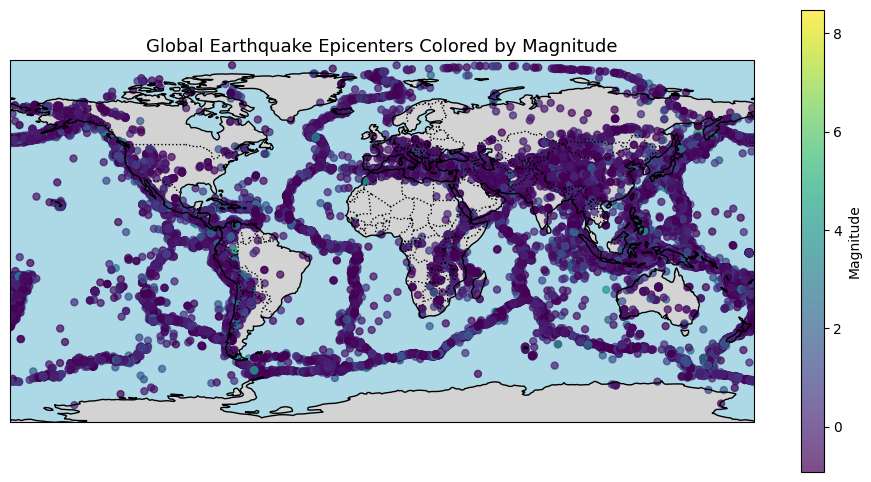

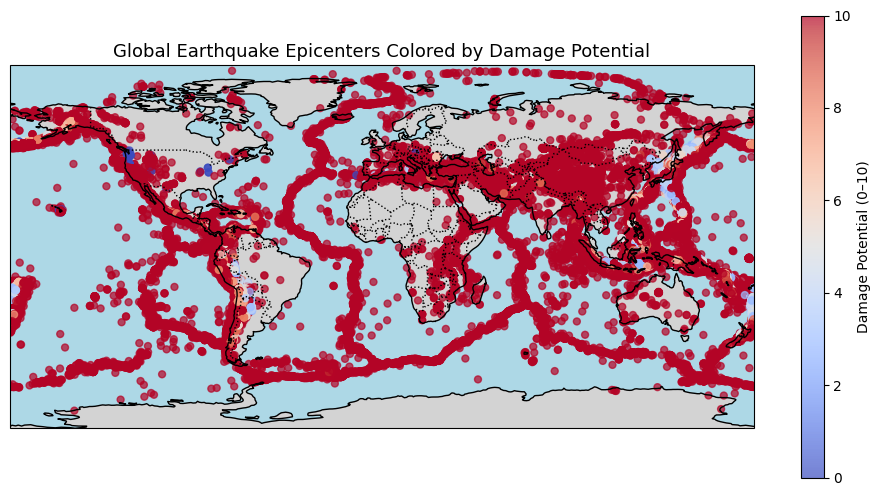

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
 #Magnitude by Location
plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

sc = plt.scatter(df['longitude'], df['latitude'], 
                 c=df['mag'], cmap='viridis', s=25, alpha=0.7,
                 transform=ccrs.PlateCarree())

plt.colorbar(sc, label='Magnitude')
plt.title('Global Earthquake Epicenters Colored by Magnitude', fontsize=13)
plt.show()
#damage potential by location
plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

sc = plt.scatter(df['longitude'], df['latitude'], 
                 c=df['damage_potential'], cmap='coolwarm', s=25, alpha=0.7,
                 transform=ccrs.PlateCarree())

plt.colorbar(sc, label='Damage Potential (0–10)')
plt.title('Global Earthquake Epicenters Colored by Damage Potential', fontsize=13)
plt.show()


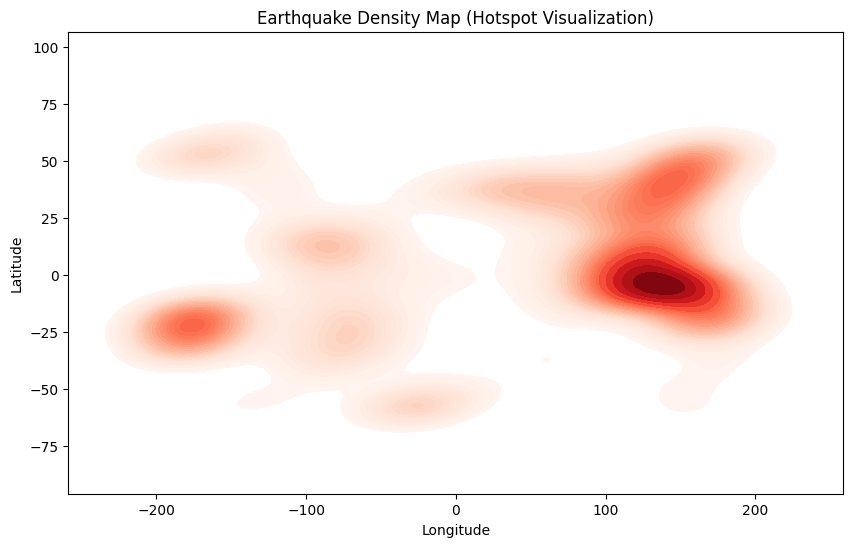

In [ ]:
#heatmap- earthquake hotspots(kdeplot-kernal density estimate (smooth 2d heatmap))
#shows areas with more earthquakes
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df.sample(10000, random_state=42), 
    x='longitude', y='latitude',
    fill=True, cmap='Reds', levels=30, thresh=0.1
)
plt.title('Earthquake Density Map (Hotspot Visualization)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


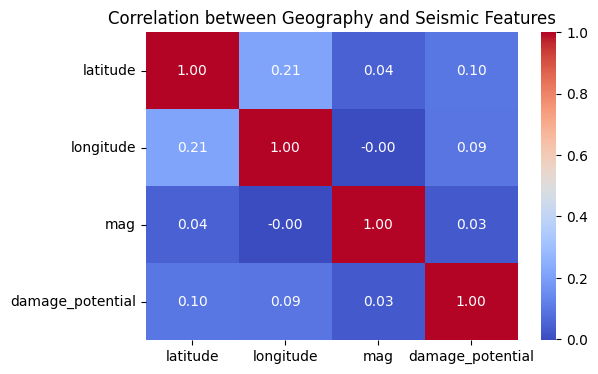

C:\Users\SRIVIDYA GAJJALA\AppData\Local\Temp\ipykernel_16584\60415504.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_summary = df.groupby(['lat_bin', 'lon_bin'])['damage_potential'].mean().unstack()


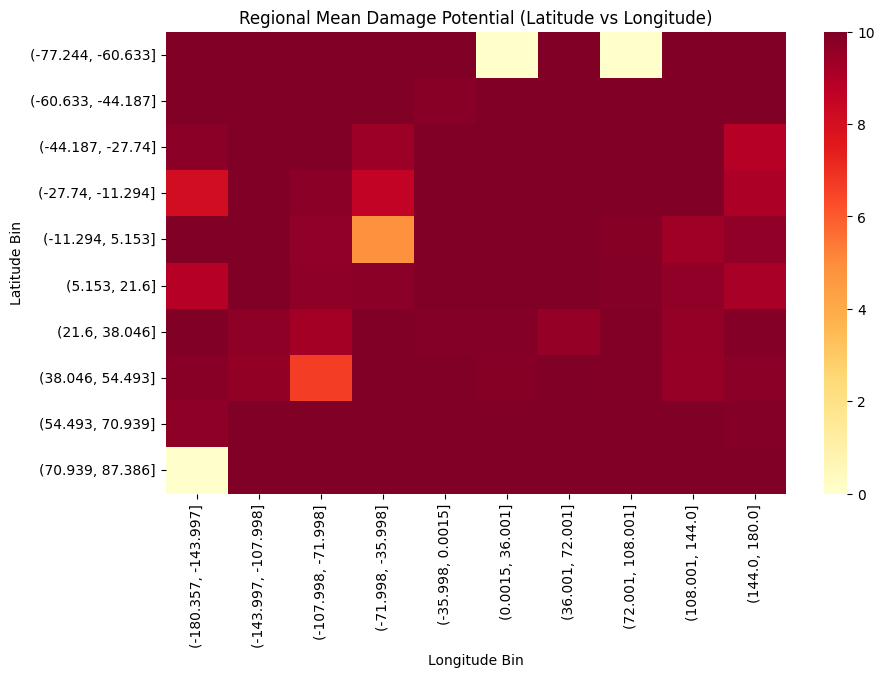

In [8]:
#correlation between coordinates(latitiude and longitude) and seismic feautures(mag,damage_potential)
corr_geo = df[['latitude', 'longitude', 'mag', 'damage_potential']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_geo, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Geography and Seismic Features')
plt.show()
# Regional Risk Summary (Binning by Latitude/Longitude)
#damage_potential in each region
# Define geographic bins (for example, 5-degree ranges)
df['lat_bin'] = pd.cut(df['latitude'], bins=10)
df['lon_bin'] = pd.cut(df['longitude'], bins=10)

# Calculate average damage potential per region
region_summary = df.groupby(['lat_bin', 'lon_bin'])['damage_potential'].mean().unstack()
region_summary = region_summary.fillna(0)
plt.figure(figsize=(10,6))
sns.heatmap(region_summary, cmap='YlOrRd')
plt.title('Regional Mean Damage Potential (Latitude vs Longitude)')
plt.xlabel('Longitude Bin')
plt.ylabel('Latitude Bin')
plt.show()


*in the geographical world map it shows the magnitude and damage potential at areas using latitude and longitude features

*latitude -25 to 25 and longitude 100 to 200 shows red spots indicating more no.of earthquakes in that region.

*no relation is seen between coordinates and seismic feautres.

*We divided latitude and longitude into 10 bins to compute the mean damage potential in each region.
The resulting heatmap highlights geographical zones with higher damage risk.

EDA Task 3 — Magnitude and Damage Potential Relationship

To analyze how earthquake strength (measured by mag and Mw) relates to the damage potential — i.e., how destructive an earthquake becomes as its magnitude increases.

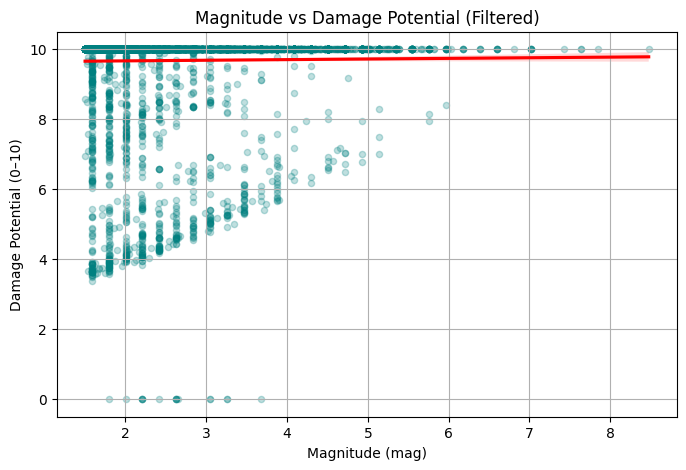

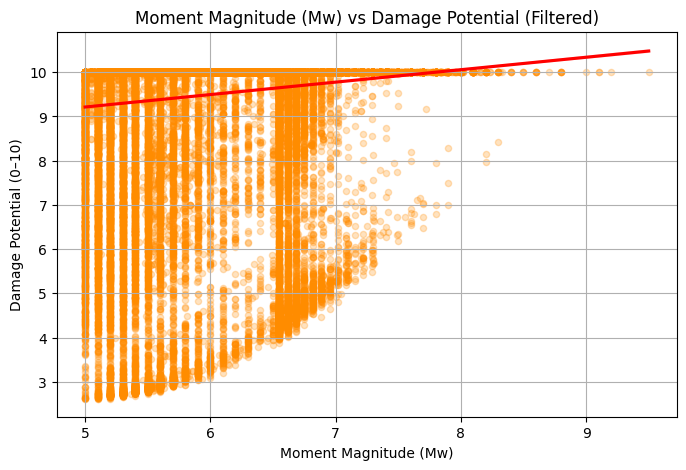

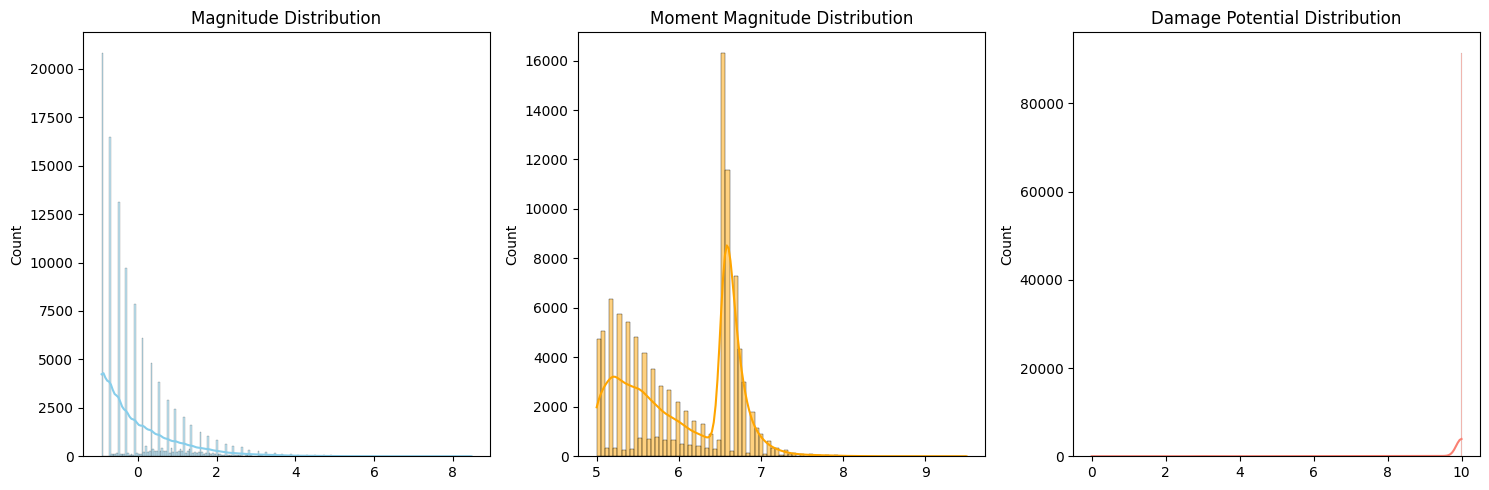

In [14]:
# Filter out unrealistic magnitudes (noise events)
df_mag = df[df['mag'] > 1.5]  # keep only meaningful earthquakes

plt.figure(figsize=(8,5))
sns.regplot( #used regplot to get scatter plot(to know relation between two variables) and get a regression line to see the relation(trend)
    data=df_mag,
    x='mag', y='damage_potential',
    scatter_kws={'alpha': 0.25, 's': 20, 'color': 'teal'},  # reduce overlap
    line_kws={'color': 'red'}  # trend line
)
plt.title('Magnitude vs Damage Potential (Filtered)')
plt.xlabel('Magnitude (mag)')
plt.ylabel('Damage Potential (0–10)')
plt.grid(True)
plt.show()

# moment magnitude vs damage potential.Mw is accurate for larger quakes.
# Filter out unrealistic or very small moment magnitudes
df_mw = df[df['Mw'] > 1.5]

plt.figure(figsize=(8,5))
sns.regplot(
    data=df_mw,
    x='Mw', y='damage_potential',
    scatter_kws={'alpha': 0.25, 's': 20, 'color': 'darkorange'},
    line_kws={'color': 'red'}
)
plt.title('Moment Magnitude (Mw) vs Damage Potential (Filtered)')
plt.xlabel('Moment Magnitude (Mw)')
plt.ylabel('Damage Potential (0–10)')
plt.grid(True)
plt.show()

#distribution histograms(with kernal density estimate curves)
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(df['mag'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Magnitude Distribution')

sns.histplot(df['Mw'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Moment Magnitude Distribution')

sns.histplot(df['damage_potential'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Damage Potential Distribution')

for ax in axes:
    ax.set_xlabel('')
plt.tight_layout()
plt.show()


*magnitude and damage potential are related.With increase in magnitude,the damage potential increases.

*The magnitude distribution is heavily right-skewed, showing that small-magnitude earthquakes occur much more frequently, while large earthquakes are rare.

*Mw distribution shows moderate to strong earthquakes.

*Damage potential is highly skewed toward the maximum value (10), indicating that most recorded earthquakes were classified as high-damage events

EDA Task 4 — Depth Analysis and Its Impact

To investigate how earthquake depth affects:

its magnitude, and

its damage potential.

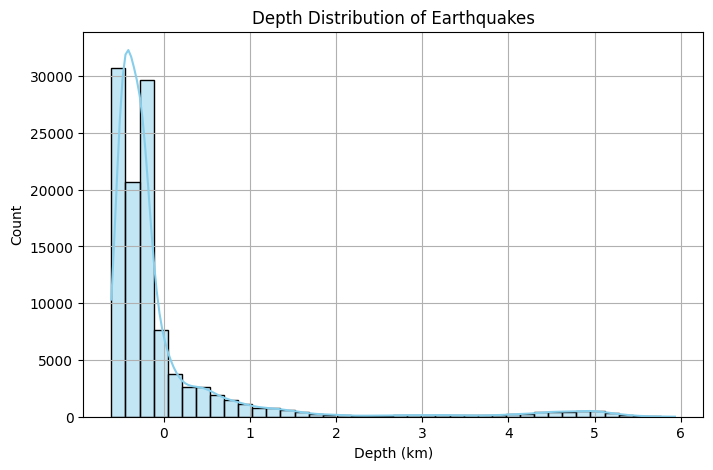

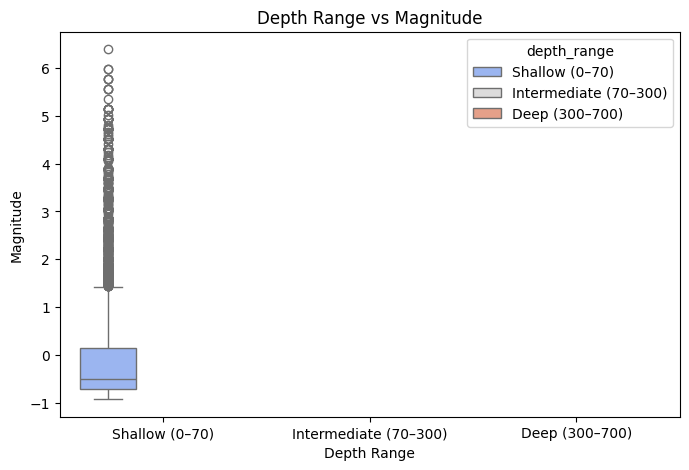

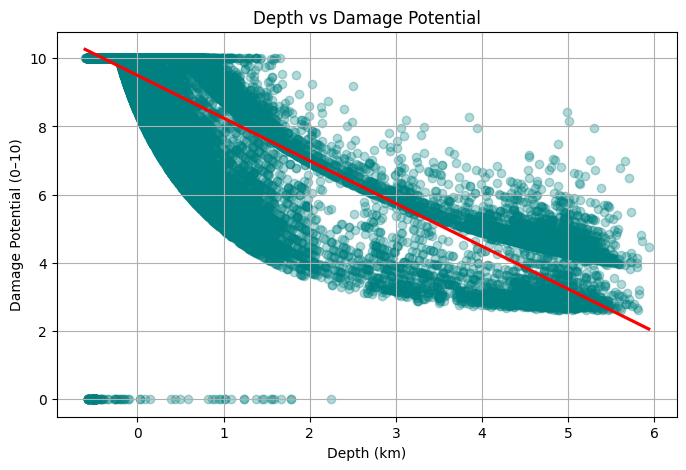

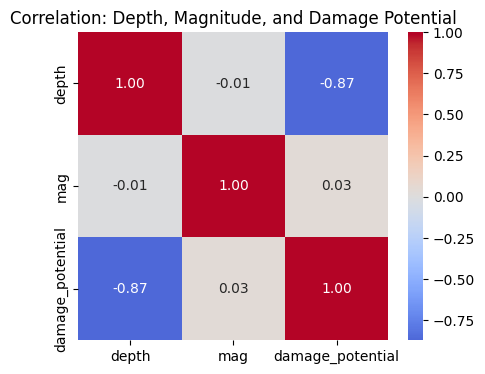

C:\Users\SRIVIDYA GAJJALA\AppData\Local\Temp\ipykernel_16584\387038565.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  depth_damage_summary = df.groupby('depth_category')['damage_potential'].mean().reset_index()
C:\Users\SRIVIDYA GAJJALA\AppData\Local\Temp\ipykernel_16584\387038565.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=depth_damage_summary, x='depth_category', y='damage_potential', palette='YlOrRd')


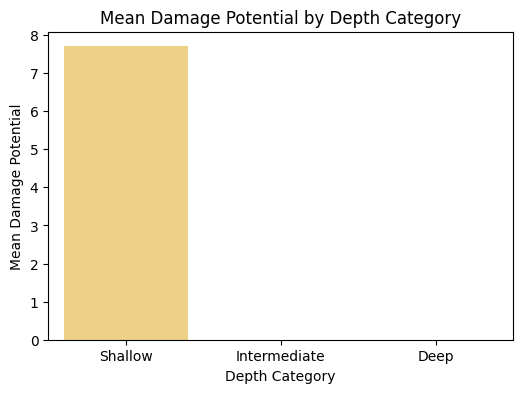

,depth_category,damage_potential
0,Shallow,7.699821
1,Intermediate,NaN
2,Deep,NaN


In [24]:
# Depth Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['depth'], bins=40, kde=True, color='skyblue')
plt.title('Depth Distribution of Earthquakes')
plt.xlabel('Depth (km)')
plt.ylabel('Count')
plt.grid(True)
plt.show()
#depth vs magnitude
df['depth_range'] = pd.cut(
    df['depth'],
    bins=[0,70,300,700],
    labels=["Shallow (0–70)", "Intermediate (70–300)", "Deep (300–700)"]
)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='depth_range', y='mag',hue='depth_range', palette='coolwarm')
plt.title('Depth Range vs Magnitude')
plt.xlabel('Depth Range')
plt.ylabel('Magnitude')
plt.show()
#depth vs damage potential
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='depth', y='damage_potential', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})
plt.title('Depth vs Damage Potential')
plt.xlabel('Depth (km)')
plt.ylabel('Damage Potential (0–10)')
plt.grid(True)
plt.show()

#correlation analysis
corr_depth = df[['depth', 'mag', 'damage_potential']].corr(method='pearson')
plt.figure(figsize=(5,4))
sns.heatmap(corr_depth, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation: Depth, Magnitude, and Damage Potential')
plt.show()
#average damage by depth category
df['depth_category'] = pd.cut(df['depth'], bins=[0,70,300,700],
                              labels=['Shallow', 'Intermediate', 'Deep'])
depth_damage_summary = df.groupby('depth_category')['damage_potential'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=depth_damage_summary, x='depth_category', y='damage_potential', palette='YlOrRd')
plt.title('Mean Damage Potential by Depth Category')
plt.xlabel('Depth Category')
plt.ylabel('Mean Damage Potential')
plt.show()

depth_damage_summary



*for most of the earthquakes Depth is below 0km indicating shallow earthquakes.

*if we observe depth vs magnitude,shallow earthquakes are more and with a magnitude less than 0.5 are more likely to be seen and mean magnitude is 0.5 and there are more outliers detected in the shallow range.

*In correlation analysis and regplot of depth vs magnitude potential we can see there is strong negative correlation between depth and damage potential indicating shallow earthquakes cause far greater surface destruction and Deeper earthquakes have much lower damage potential

*there are only earthquakes with shallow category and its mean value is 7.7

EDA Task 5 – Categorical Feature Analysis

To explore relationships between categorical features and numerical features (like mag and damage_potential) to uncover patterns in earthquake classification and reliability.

Magnitude Type counts:
 magType
mb            45084
mw            24335
mwc           17458
mww           15652
ms             3157
mwb            3082
ml              485
mwr             451
md               50
mh               23
m                21
Mi               12
mwp               9
uk                8
fa                5
ml(texnet)        4
ms_20             3
mc                2
lg                1
mb_lg             1
ma                1
mlg               1
Md                1
Ml                1
Mb                1
Name: count, dtype: int64 

Earthquake Type counts:
 type
earthquake           109356
nuclear explosion       424
volcanic eruption        54
explosion                10
landslide                 2
mine collapse             1
rock burst                1
Name: count, dtype: int64 

Status counts:
 status
reviewed     109744
automatic       104
Name: count, dtype: int64 



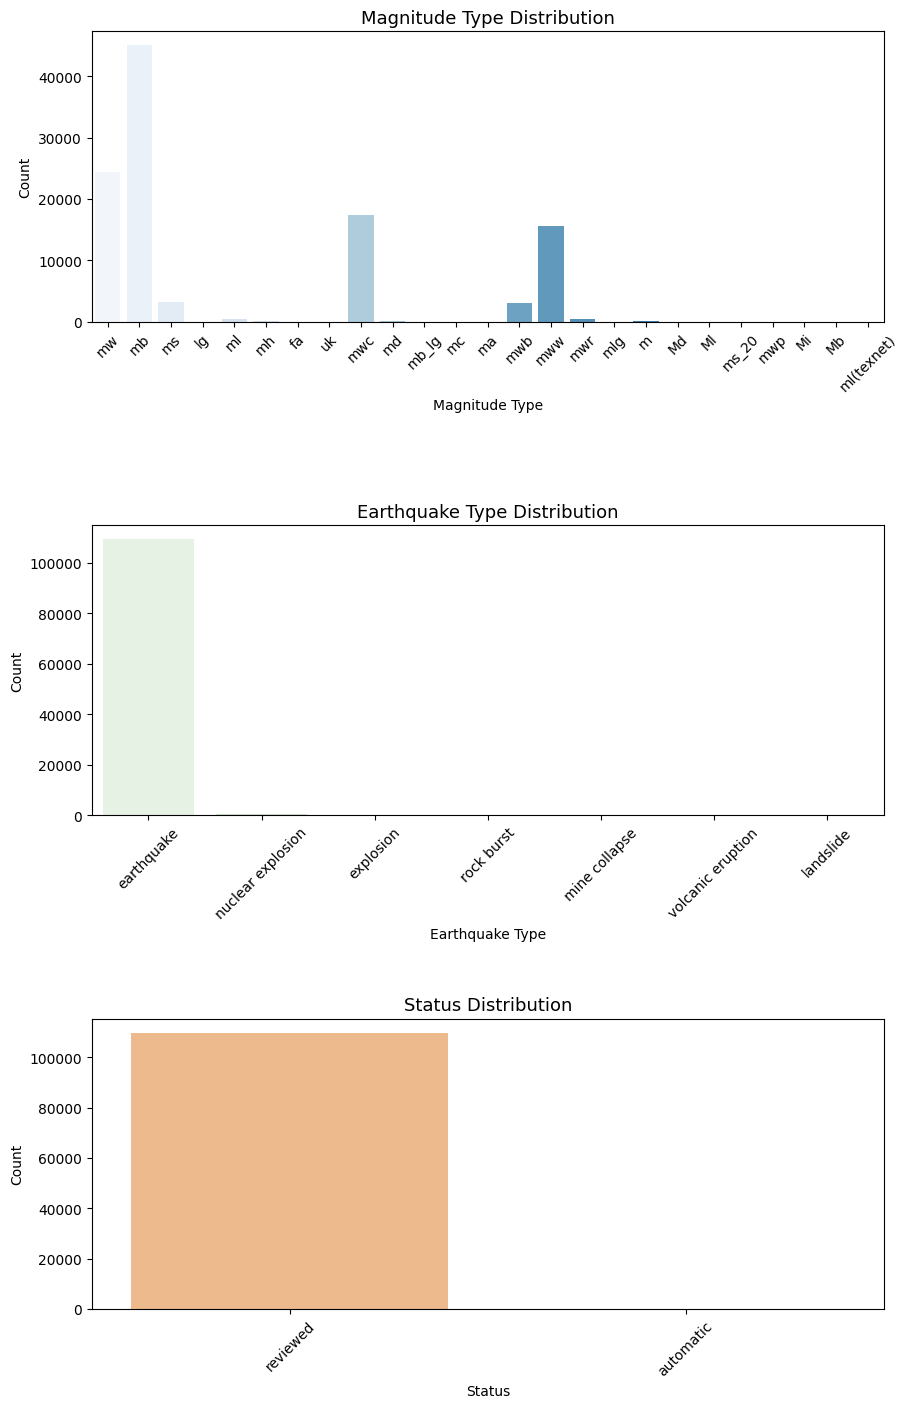

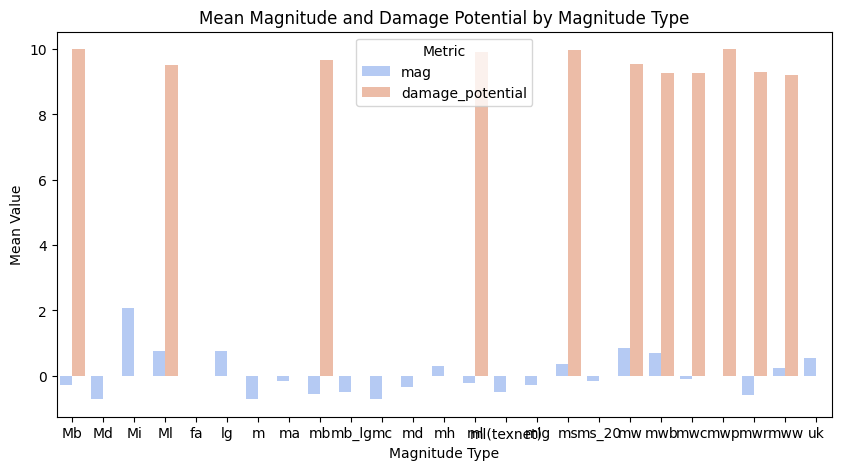

np.float64(0.049878035604094116)

In [28]:
# Value Counts
print("Magnitude Type counts:\n", df['magType'].value_counts(), "\n")
print("Earthquake Type counts:\n", df['type'].value_counts(), "\n")
print("Status counts:\n", df['status'].value_counts(), "\n")
#Bar charts and category events
# Create 3 subplots stacked vertically
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

#  Magnitude Type Distribution
sns.countplot(data=df, x='magType', hue='magType', palette='Blues', ax=axes[0])
axes[0].set_title('Magnitude Type Distribution', fontsize=13)
axes[0].set_xlabel('Magnitude Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)  # rotate labels if long names

# Earthquake Type Distribution
sns.countplot(data=df, x='type', hue='type', palette='Greens', ax=axes[1])
axes[1].set_title('Earthquake Type Distribution', fontsize=13)
axes[1].set_xlabel('Earthquake Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Status Distribution
sns.countplot(data=df, x='status', hue='status', palette='Oranges', ax=axes[2])
axes[2].set_title('Status Distribution', fontsize=13)
axes[2].set_xlabel('Status')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout(pad=4.0)
plt.show()
# Mean magnitude and damage by magnitude type
mag_summary = df.groupby('magType')[['mag','damage_potential']].mean().reset_index()

plt.figure(figsize=(10,5))
mag_summary_melt = mag_summary.melt(id_vars='magType', value_vars=['mag','damage_potential'],
                                    var_name='Metric', value_name='MeanValue')
sns.barplot(data=mag_summary_melt, x='magType', y='MeanValue', hue='Metric', palette='coolwarm')
plt.title('Mean Magnitude and Damage Potential by Magnitude Type')
plt.xlabel('Magnitude Type'); plt.ylabel('Mean Value')
plt.show()
#Cross-Tabulation
pd.crosstab(df['type'], df['status'])
#Association between magnitudeType and type
import numpy as np
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramers_v(df['magType'], df['type'])




*mb type magnitude records are more compared to others.Others include mw,mwc,mww.

*Earthquake type is most likely to be seen,it helps because we need naturally occuring events not man made.

*Most of the data was verified showing that the data quality is good and reliable.

*Though the magnitude is seen small but the damage potential is higher,almost equivalent to 10.

*There is no association between magnitudeType and type of the event occured.

Hypothesis 1 – Magnitude Difference by Earthquake Type

check if different earthquake types (earthquake, explosion) have significantly different mean magnitudes.

In [29]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable


In [31]:
from scipy.stats import f_oneway, kruskal

# Grouping magnitude data by earthquake type
types = ['earthquake', 'nuclear explosion', 'explosion']  # main types
groups = [df[df['type']==t]['mag'].dropna() for t in types]

# Normal ANOVA
F, p = f_oneway(*groups)
print("ANOVA F =", round(F,3), "p =", round(p,6))

# If data is not normal, use Kruskal-Wallis
H, p_kruskal = kruskal(*groups)
print("Kruskal-Wallis H =", round(H,3), "p =", round(p_kruskal,6))


ANOVA F = 11.243 p = 1.3e-05
Kruskal-Wallis H = 75.349 p = 0.0


as p<0.05 we Reject H0  At least one earthquake type has a significantly different mean magnitude.

HYPOTHESIS-2:Damage Potential by Magnitude Categories

Check if different magnitude have different damage potential.

In [32]:
from scipy.stats import ttest_ind, mannwhitneyu

# Split data by median magnitude
median_mag = df['mag'].median()
high_mag = df[df['mag'] >= median_mag]['damage_potential'].dropna()
low_mag = df[df['mag'] < median_mag]['damage_potential'].dropna()

# t-test
t_stat, p_val = ttest_ind(high_mag, low_mag, equal_var=False)
print("t-stat =", round(t_stat,3), "p =", round(p_val,6))

t-stat = -2.663 p = 0.007746


as p<0.05 high-magnitude earthquakes have significantly different damage potential than low-magnitude ones. 

Hypothesis 3: Depth Impact on Magnitude

To check earthquake depth significantly correlate with magnitude

In [33]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation
corr, p = pearsonr(df['depth'].dropna(), df['mag'].dropna())
print("Pearson r =", round(corr,3), "p =", round(p,6))

# Spearman if relationship is non-linear
rho, p_s = spearmanr(df['depth'].dropna(), df['mag'].dropna())
print("Spearman rho =", round(rho,3), "p =", round(p_s,6))


Pearson r = -0.01 p = 0.000868
Spearman rho = -0.049 p = 0.0


as both correlations are close to 0 Depth does not meaningfully affect earthquake magnitude.

Hypothesis 4: Temporal Seasonality in Earthquake Frequency

Are earthquakes seasonal?

In [37]:
from scipy.stats import chisquare

# Count earthquakes per month using the 'Month' column
monthly_counts = df['Month'].value_counts().sort_index()

# Expected counts assuming uniform distribution
expected = [monthly_counts.mean()] * 12

# Chi-square test
chi_stat, p_val = chisquare(monthly_counts, f_exp=expected)
print("Chi-square =", round(chi_stat,3), "p =", round(p_val,6))




Chi-square = 312.37 p = 0.0


as p<0.05 there is a seasonal effect

Hypothesis 5: RMS Variability by Magnitude Type

to check whether different magnitude types show different RMS variability

In [38]:
from scipy.stats import f_oneway, levene
import statsmodels.stats.multicomp as mc

# Group RMS by magType
groups = [df[df['magType']==t]['rms'].dropna() for t in df['magType'].unique() if df[df['magType']==t]['rms'].dropna().size>5]

# Levene's test for equal variance
stat, p_levene = levene(*groups)
print("Levene's stat =", round(stat,3), "p =", round(p_levene,6))

# ANOVA
F, p_anova = f_oneway(*groups)
print("ANOVA F =", round(F,3), "p =", round(p_anova,6))

# Post-hoc Tukey if ANOVA significant
comp = mc.MultiComparison(df['rms'], df['magType'])
tukey_result = comp.tukeyhsd()
print(tukey_result)


Levene's stat = 400.93 p = 0.0
ANOVA F = 435.323 p = 0.0
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
        Mb         Md   -1.335    1.0   -6.379  3.7089  False
        Mb         Mi   1.3147 0.9999  -2.3976  5.0269  False
        Mb         Ml  -1.6211    1.0   -6.665  3.4229  False
        Mb         fa   0.1097    1.0  -3.7973  4.0167  False
        Mb         lg   0.1672    1.0  -4.8768  5.2111  False
        Mb          m   0.0008    1.0  -3.6497  3.6514  False
        Mb         ma  -2.6382 0.9723  -7.6822  2.4057  False
        Mb         mb   0.0664    1.0  -3.5003   3.633  False
        Mb      mb_lg   0.0716    1.0  -4.9724  5.1155  False
        Mb         mc  -1.9342 0.9969  -6.3024   2.434  False
        Mb         md  -2.0863 0.9183  -5.6884  1.5158  False
        Mb         mh    7.983    0.0   4.3397 11.6264   True
        Mb   

This means different magnitude types have systematically different rms